In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [5]:
os.path.dirname(os.getcwd()).replace('\\', '/') + '/full_view/Balbc_10x_2k_.jpg'

'c:/Users/Yarik/OneDrive/Рабочий стол/python_modules/Four_host_species_OF/full_view/Balbc_10x_2k_.jpg'

In [8]:
input_path = Path(os.path.dirname(os.getcwd()).replace('\\', '/') + '/full_view/Balbc_10x_2k_.jpg')
output_path = Path(os.path.dirname(os.getcwd()).replace('\\', '/') + '/full_view/Balbc_10x_2k__cr.jpg')

In [15]:
input_path = Path(os.path.dirname(os.getcwd()).replace('\\', '/') + '/full_view/Balbc_10x_2k_.jpg')

In [ ]:
# --------------------------------------------------
# File paths
# --------------------------------------------------
input_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k.jpg"
output_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k_corrected.png"

In [21]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
background_blur = 151
correction_strength = 0.85
clahe_clip_limit = 1.5
clahe_grid_size = (16, 16)


In [22]:
# --------------------------------------------------
# Load image using Pillow
# --------------------------------------------------
with Image.open(input_path) as pil_image:
    rgb_image = pil_image.convert("RGB")

# Convert Pillow RGB image to OpenCV BGR format
rgb = np.array(rgb_image)
bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

print("Image loaded:", bgr.shape)

Image loaded: (3445, 1417, 3)


In [23]:
# --------------------------------------------------
# Create a tissue mask
# --------------------------------------------------
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]
value = hsv[:, :, 2]

# Tissue is usually more saturated than the gray checkerboard background
tissue_mask = ((saturation > 18) & (value < 250)).astype(np.uint8) * 255

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_CLOSE,
    kernel
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_OPEN,
    kernel
)

tissue_mask = cv2.dilate(
    tissue_mask,
    np.ones((9, 9), np.uint8)
)

In [24]:
# --------------------------------------------------
# Convert to Lab color space
# --------------------------------------------------
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

lightness, a_channel, b_channel = cv2.split(lab)

In [25]:
# --------------------------------------------------
# Estimate and correct uneven illumination
# --------------------------------------------------
background = cv2.GaussianBlur(
    lightness,
    (background_blur, background_blur),
    0
)

background = np.maximum(
    background.astype(np.float32),
    1.0
)

lightness_float = lightness.astype(np.float32)

corrected_lightness = (
    lightness_float / background
)

# Use the median tissue brightness as the target level
tissue_pixels = corrected_lightness[tissue_mask > 0]

if tissue_pixels.size > 0:
    target_brightness = np.median(
        lightness.astype(np.float32)[tissue_mask > 0]
    )
else:
    target_brightness = np.median(lightness)

corrected_lightness = corrected_lightness * target_brightness

corrected_lightness = np.clip(
    corrected_lightness,
    0,
    255
).astype(np.uint8)


# Blend corrected and original lightness
corrected_lightness = cv2.addWeighted(
    lightness,
    1.0 - correction_strength,
    corrected_lightness,
    correction_strength,
    0
)


In [26]:
# --------------------------------------------------
# Apply mild local contrast enhancement
# --------------------------------------------------
clahe = cv2.createCLAHE(
    clipLimit=clahe_clip_limit,
    tileGridSize=clahe_grid_size
)

enhanced_lightness = clahe.apply(corrected_lightness)


In [27]:

# --------------------------------------------------
# Preserve the original checkerboard background
# --------------------------------------------------
mask_float = tissue_mask.astype(np.float32) / 255.0
mask_float = cv2.GaussianBlur(
    mask_float,
    (21, 21),
    0
)

final_lightness = (
    enhanced_lightness.astype(np.float32) * mask_float
    + lightness.astype(np.float32) * (1.0 - mask_float)
)

final_lightness = np.clip(
    final_lightness,
    0,
    255
).astype(np.uint8)

In [28]:
# --------------------------------------------------
# Reconstruct corrected color image
# --------------------------------------------------
corrected_lab = cv2.merge([
    final_lightness,
    a_channel,
    b_channel
])

corrected_bgr = cv2.cvtColor(
    corrected_lab,
    cv2.COLOR_LAB2BGR
)

corrected_rgb = cv2.cvtColor(
    corrected_bgr,
    cv2.COLOR_BGR2RGB
)

In [29]:
# --------------------------------------------------
# Save with Pillow
# --------------------------------------------------
corrected_pil = Image.fromarray(corrected_rgb)
corrected_pil.save(output_path)

print("Correction completed.")
print("Saved to:", output_path)

Correction completed.
Saved to: c:\Users\Yarik\OneDrive\Рабочий стол\python_modules\Four_host_species_OF\full_view\Balbc_10x_2k_corrected.png


In [30]:
def show_bgr(img, title, max_width=1200):
    """
    Display a BGR OpenCV image correctly in a Python file.
    Large images are resized only for display.
    """

    if img is None:
        raise ValueError("The image is empty.")

    display_img = img[:, :, :3] if img.ndim == 3 else img

    height, width = display_img.shape[:2]
    scale = min(1.0, max_width / width)

    if scale < 1.0:
        display_img = cv2.resize(
            display_img,
            (
                int(width * scale),
                int(height * scale)
            ),
            interpolation=cv2.INTER_AREA
        )

    plt.figure(figsize=(16, 10))

    if display_img.ndim == 3:
        plt.imshow(
            cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
        )
    else:
        plt.imshow(
            display_img,
            cmap="gray"
        )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

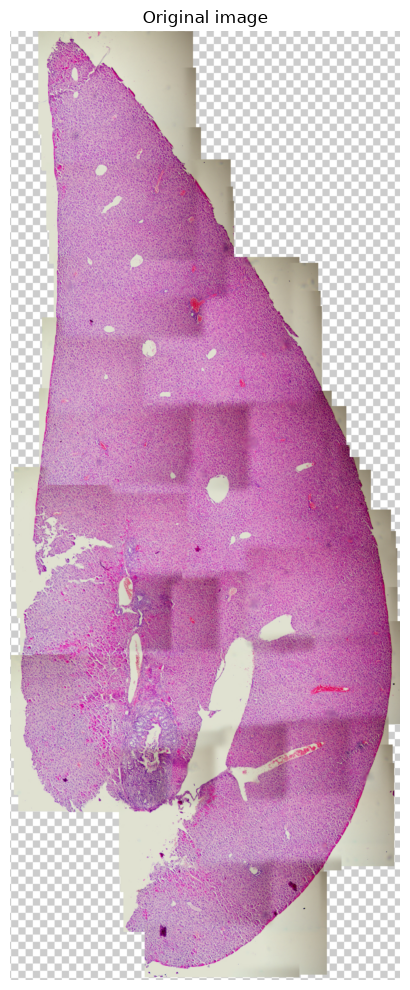

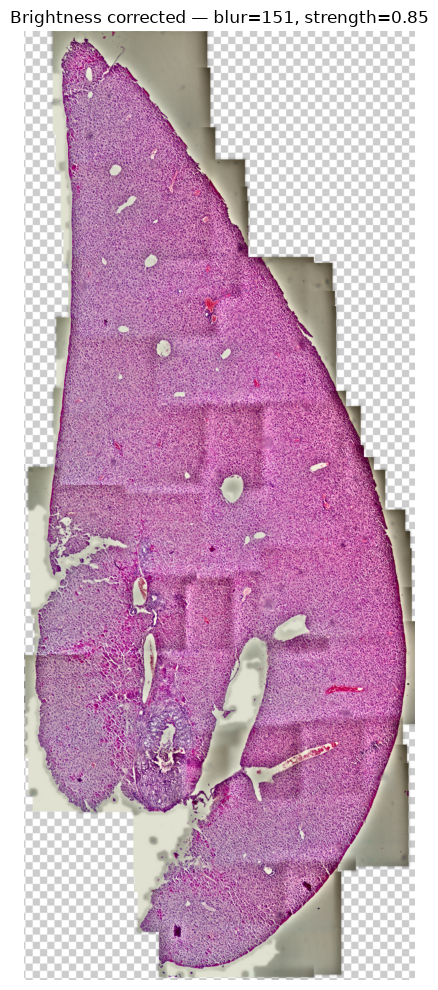

In [31]:
show_bgr(bgr, "Original image")

show_bgr(
    corrected_bgr,
    f"Brightness corrected — "
    f"blur={background_blur}, "
    f"strength={correction_strength}"
)